# Lab 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

In [6]:
class GaussianBanditEnv(gym.Env):
    def __init__(self, k=10):
        super().__init__()
        self.k = k
        self.action_space = spaces.Discrete(k)
        self.observation_space = spaces.Discrete(1)  # dummy state
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.q_true = np.random.normal(0, 1, self.k)
        self.optimal_action = np.argmax(self.q_true)
        return 0, {}

    def step(self, action):
        reward = np.random.normal(self.q_true[action], 1)
        done = False
        return 0, reward, done, False, {}


In [7]:
class EpsilonGreedyAgent:
    def __init__(self, k, epsilon):
        self.k = k
        self.epsilon = epsilon
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)
        return np.argmax(self.Q)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

In [8]:
class UCBAgent:
    def __init__(self, k, c):
        self.k = k
        self.c = c
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.k)
        self.N = np.zeros(self.k)
        self.t = 0

    def select_action(self):
        self.t += 1
        for a in range(self.k):
            if self.N[a] == 0:
                return a
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


In [9]:
def run_experiment(agent_class, param, steps=2000, runs=1000, k=10):
    rewards = np.zeros((runs, steps))
    optimal = np.zeros((runs, steps))

    for run in range(runs):
        env = GaussianBanditEnv(k)
        state, _ = env.reset()
        agent = agent_class(k, param)

        for t in range(steps):
            action = agent.select_action()
            _, reward, _, _, _ = env.step(action)

            agent.update(action, reward)

            rewards[run, t] = reward
            optimal[run, t] = (action == env.optimal_action)

    avg_rewards = rewards.mean(axis=0)
    optimal_pct = optimal.mean(axis=0)

    return avg_rewards, optimal_pct

In [10]:
steps = 2000
runs = 1000
k = 10

# Epsilon values
epsilons = [0.01, 0.1, 0.2]
ucb_cs = [0.5, 1, 2]

results = {}

In [11]:
for eps in epsilons:
    avg_r, opt = run_experiment(EpsilonGreedyAgent, eps, steps, runs, k)
    results[f"eps={eps}"] = (avg_r, opt)

In [12]:
for c in ucb_cs:
    avg_r, opt = run_experiment(UCBAgent, c, steps, runs, k)
    results[f"ucb c={c}"] = (avg_r, opt)

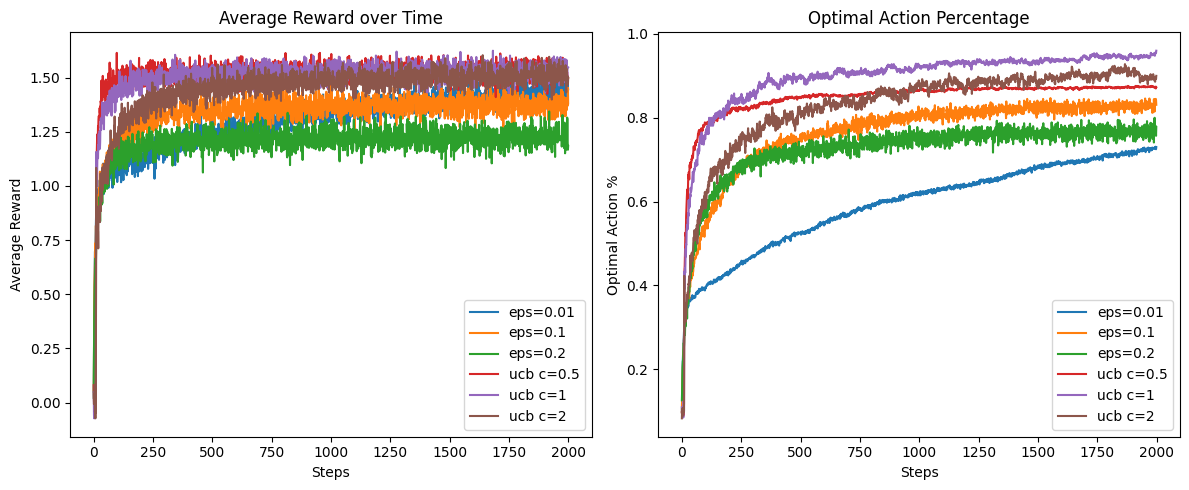

In [13]:
# Plot Results
# =============================
plt.figure(figsize=(12, 5))

# Average Reward
plt.subplot(1, 2, 1)
for key in results:
    plt.plot(results[key][0], label=key)
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()

# Optimal Action %
plt.subplot(1, 2, 2)
for key in results:
    plt.plot(results[key][1], label=key)
plt.xlabel("Steps")
plt.ylabel("Optimal Action %")
plt.title("Optimal Action Percentage")
plt.legend()

plt.tight_layout()
plt.show()
